In [10]:
import sys, pathlib
import pandas as pd
# Add typing import to handle Optional type hint
from typing import Optional, List, Dict, Any  # Import typing module with commonly used types

proj_src = pathlib.Path().resolve().parent / "motec-ld-export-ui" / "motec-to-csv" / "src"
sys.path.append(str(proj_src))
from motec_converter import parse_race_data, to_pandas
sys.path.remove(str(proj_src))
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

In [9]:
#13 March:

dyno_df = pd.read_csv("13 March/dyno.csv", index_col=0, parse_dates=True)

motec_files = [
    "13 March/speed_ramp_40-100_ramprate45_pl150.ld",
    "13 March/speedramp_run2.ld"
]

dyno_ids = [
    "MUREV2025.0008",
    "MUREV2025.0010"
]

def process_and_compute_efficiency_day1(dyno_df, motec_files, dyno_ids, target_torque=150,
                                   rpm_diff_tol=None, rolling_window=3, plot=True):
    """
    Process dyno and MoTeC data and compute motor efficiency.
    
    Parameters:
    - dyno_df: DataFrame with dyno data indexed by run ID
    - motec_files: list of MoTeC file paths
    - dyno_ids: list of corresponding dyno IDs for each MoTeC file
    - target_torque: torque to filter by (Nm)
    - rpm_diff_tol: if given, only match points within ±rpm_diff_tol
    - rolling_window: window for rolling mean smoothing
    - plot: if True, generate scatter plot of efficiency vs RPM
    
    Returns:
    - combined_df: concatenated DataFrame with efficiency calculations
    """
    
    all_runs = []
    
    for motec_file, dyno_id in zip(motec_files, dyno_ids):
        # --- Load dyno ---
        cur_dyno_df = dyno_df.loc[dyno_id].copy()
        cur_dyno_df = cur_dyno_df.dropna(subset=['Motor Speed (rpm)', 'Motor Torque (Nm)'])
        
        rpm_min = cur_dyno_df["Motor Speed (rpm)"].min()
        rpm_max = cur_dyno_df["Motor Speed (rpm)"].max()
        
        # --- Load MoTeC ---
        race_data = parse_race_data(motec_file)
        segments = to_pandas(race_data)
        motec_df = pd.concat(segments)
        
        # Filter by RPM range and target torque
        motec_trim = motec_df[
            (motec_df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
            (motec_df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
            (motec_df['Car.Data.Inverter.InverterCalculatedTorque'] == target_torque)
        ].copy()
        
        # Only keep monotonic increasing RPM
        motec_trim = motec_trim[motec_trim["Car.Data.Motor.MotorRPM"].diff() > 0]
        
        # Rolling mean smoothing
        motec_trim = motec_trim.rolling(rolling_window).mean().dropna()
        
        # --- Nearest neighbor matching ---
        dyno_features = cur_dyno_df[['Motor Speed (rpm)', 'Motor Torque (Nm)']].to_numpy()
        motec_features = motec_trim[['Car.Data.Motor.MotorRPM', 'Car.Data.Inverter.InverterCalculatedTorque']].to_numpy()
        
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(dyno_features)
        distances, indices = nn.kneighbors(motec_features)
        
        matched_dyno = cur_dyno_df.iloc[indices.flatten()].reset_index(drop=True)
        matched_motec = motec_trim.reset_index(drop=True)
        
        # Optional RPM difference filter
        if rpm_diff_tol is not None:
            rpm_diff = np.abs(matched_dyno['Motor Speed (rpm)'] - matched_motec['Car.Data.Motor.MotorRPM'])
            keep = rpm_diff <= rpm_diff_tol
            matched_dyno = matched_dyno[keep].reset_index(drop=True)
            matched_motec = matched_motec[keep].reset_index(drop=True)
        
        # --- Compute efficiency ---
        matched_df = matched_motec.copy()
        matched_df['P_out'] = matched_dyno['Motor Torque (Nm)'] * 2*np.pi*matched_dyno['Motor Speed (rpm)']/60 / 1000
        matched_df['P_in'] = matched_motec['Car.Data.Battery.BatteryPower'] / 100000
        matched_df['eff'] = matched_df['P_out'] / matched_df['P_in']
        
        all_runs.append(matched_df)
    
    # --- Combine all runs ---
    combined_df = pd.concat(all_runs, ignore_index=True)
    combined_df = combined_df[combined_df['eff'] < 1]  # sanity filter
    
    # --- Plot ---
    if plot:
        plt.figure(figsize=(10,5))
        plt.scatter(combined_df['Car.Data.Motor.MotorRPM'], combined_df['eff'], s=5, alpha=0.7)
        plt.xlabel("RPM")
        plt.ylabel("Efficiency")
        plt.title(f"Motor Efficiency vs RPM (Torque = {target_torque} Nm)")
        plt.grid(True)
        plt.show()
    
    return combined_df

#combined_efficiency = process_and_compute_efficiency_day1(dyno_df, motec_files, dyno_ids,target_torque=150, rolling_window=3)

C:\Users\kafle\AppData\Local\Temp\ipykernel_44228\1963113086.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dyno_df = pd.read_csv("13 March/dyno.csv", index_col=0, parse_dates=True)


In [12]:
# 20 March

dyno_matched = ['speedramp4_pl80_manual_dhruv.csv',
                'speedramp4_pl80_manual_dhruv.csv',
               'speedramp7_pl110_manual_dhruv.csv']
motec_matched = ['dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv',
                 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv',
                'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv']

def _best_segment(
    motec_in_range: pd.DataFrame,
    dyno_df: pd.DataFrame,
    gap_threshold_s: float = 2.0,
    rpm_weight: float = 1.0,
    torque_weight: float = 1.0,
):
    """
    Split MoTeC data into continuous segments and choose the segment
    whose RPM + torque profile best matches the dyno trace.

    Matching is done by interpolating both traces onto a normalized
    time base and minimizing RMSE.
    """

    MOTEC_RPM = "Car.Data.Motor.MotorRPM"
    MOTEC_TORQUE = "Car.Data.Inverter.InverterCalculatedTorque"

    DYNO_RPM = "Calculated Motor RPM"
    DYNO_TORQUE = "Calculated Motor Torque"

    df = motec_in_range.copy().reset_index(drop=True)

    # Split into continuous segments
    seg_id = (df["Time"].diff() > gap_threshold_s).cumsum()
    df["_seg"] = seg_id

    # ---- Dyno normalized time axis ----
    dyno_time = dyno_df["Time (sec)"].values
    dyno_time = dyno_time - dyno_time.min()

    dyno_rpm = dyno_df[DYNO_RPM].values
    dyno_torque = dyno_df[DYNO_TORQUE].values

    # Normalize time to 0-1
    dyno_t_norm = dyno_time / dyno_time.max()

    best_score = np.inf
    best_seg = None

    for seg, grp in df.groupby("_seg"):

        if len(grp) < 10:
            continue

        # ---- MoTeC normalized time axis ----
        motec_time = grp["Time"].values
        motec_time = motec_time - motec_time.min()

        if motec_time.max() <= 0:
            continue

        motec_t_norm = motec_time / motec_time.max()

        motec_rpm = grp[MOTEC_RPM].values
        motec_torque = grp[MOTEC_TORQUE].values

        # ---- Interpolate MoTeC onto dyno normalized timeline ----
        try:
            rpm_interp = interp1d(
                motec_t_norm,
                motec_rpm,
                bounds_error=False,
                fill_value="extrapolate"
            )

            torque_interp = interp1d(
                motec_t_norm,
                motec_torque,
                bounds_error=False,
                fill_value="extrapolate"
            )

            motec_rpm_resampled = rpm_interp(dyno_t_norm)
            motec_torque_resampled = torque_interp(dyno_t_norm)

        except Exception:
            continue

        # ---- Compute RMSE ----
        rpm_rmse = np.sqrt(
            np.mean((motec_rpm_resampled - dyno_rpm) ** 2)
        )

        torque_rmse = np.sqrt(
            np.mean((motec_torque_resampled - dyno_torque) ** 2)
        )

        # ---- Combined score ----
        score = (
            rpm_weight * rpm_rmse
            + torque_weight * torque_rmse
        )

        print(
            f"Segment {seg}: "
            f"RPM RMSE={rpm_rmse:.1f}, "
            f"Torque RMSE={torque_rmse:.1f}, "
            f"Score={score:.1f}"
        )

        if score < best_score:
            best_score = score
            best_seg = seg

    print(f"Selected segment: {best_seg} (score={best_score:.1f})")

    return df[df["_seg"] == best_seg].drop(columns="_seg")
 




def process_and_compute_efficiency(dyno_files, motec_files, target_torque=150,
                                   rpm_diff_tol=5, rolling_window=3, plot=True):
    """
    Process dyno and MoTeC data and compute motor efficiency.
    
    Parameters:
    - dyno_df: DataFrame with dyno data indexed by run ID
    - motec_files: list of MoTeC file paths
    - dyno_ids: list of corresponding dyno IDs for each MoTeC file
    - target_torque: torque to filter by (Nm)
    - rpm_diff_tol: if given, only match points within ±rpm_diff_tol
    - rolling_window: window for rolling mean smoothing
    - plot: if True, generate scatter plot of efficiency vs RPM
    
    Returns:
    - combined_df: concatenated DataFrame with efficiency calculations
    """
    MOTEC_RPM = "Car.Data.Motor.MotorRPM"
    all_runs = []
    i= 0
    for motec_file, dyno_file in zip(motec_files, dyno_files):
        print(i)
        # --- Load dyno ---
        #print(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = pd.read_csv(f'20 March/Dyno_Data/{dyno_file}')
        cur_dyno_df = cur_dyno_df.dropna(subset=['Axle Speed (rpm)', 'Axle Torque (Nm)'])

        cur_dyno_df['Calculated Motor RPM'] = cur_dyno_df['Axle Speed (rpm)'] * 38/11
        cur_dyno_df['Calculated Motor Torque'] = cur_dyno_df['Axle Torque (Nm)'] * 11/38
        
        
        rpm_min = cur_dyno_df["Calculated Motor RPM"].min()
        rpm_max = cur_dyno_df["Calculated Motor RPM"].max()
        dyno_dur  = cur_dyno_df["Time (sec)"].max() - cur_dyno_df["Time (sec)"].min()
        
        # --- Load MoTeC ---
        #motec_df = motec_files
        motec_df = pd.read_csv(f'20 March/Motec_Data/CSV Export/{motec_file}', header=8, low_memory=False)
        motec_df= motec_df.iloc[1:].reset_index(drop=True)
        motec_df = motec_df.apply(pd.to_numeric, errors='coerce')
        voltage_col = 'Car.Data.Inverter.InverterDCVoltage'
        current_col = 'Car.Data.Inverter.InverterDCCurrent'
        motec_df['Battery Power (kW)'] = (motec_df[voltage_col] * motec_df[current_col] / (100000))
        
        if not (motec_df[current_col] > 0).any():
            print("WARNING: No positive DC current detected. Skipping.")
            continue

            

        #print(rpm_min, rpm_max)
        
        # Filter by RPM range and target torque
        motec_in_range = motec_df[
            (motec_df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
            (motec_df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
            (motec_df['Car.Data.Inverter.InverterCalculatedTorque'] >= target_torque) &
            (motec_df['Battery Power (kW)'] > 1)
            ].copy()

        
        motec_seg = _best_segment(
            motec_in_range,
            cur_dyno_df,
            rpm_weight=1.0,
            torque_weight=0.5,
        )
        print(f"  Best MoTeC segment: {len(motec_seg)} rows, \n"
              f" Time start: {motec_seg['Time'].max()}, Time end: {motec_seg['Time'].min()}\n"
              f"duration {motec_seg['Time'].max()-motec_seg['Time'].min():.1f} s, "
              f"RPM {motec_seg[MOTEC_RPM].min():.0f}–{motec_seg[MOTEC_RPM].max():.0f}")
 
        # ── Keep only the monotonically-increasing RPM portion ───────────────
        motec_mono = motec_seg[motec_seg[MOTEC_RPM].diff() > 0]
        motec_mono = motec_mono.rolling(rolling_window).mean().dropna()
        print(f"  After monotonic + rolling mean: {len(motec_mono)} rows")
 
        if motec_mono.empty:
            print("  No monotonic data — skipping.")
            continue
 
        # ── Nearest-neighbour match on RPM only ──────────────────────────────
        # InverterCalculatedTorque saturates at a command limit (not real output
        # torque) so it cannot be used as a matching feature.
        dyno_rpm   = cur_dyno_df["Calculated Motor RPM"].to_numpy().reshape(-1, 1)
        motec_rpm  = motec_mono[MOTEC_RPM].to_numpy().reshape(-1, 1)
 
        scaler = StandardScaler()
        dyno_scaled  = scaler.fit_transform(dyno_rpm)
        motec_scaled = scaler.transform(motec_rpm)
 
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(dyno_scaled)
        _, indices = nn.kneighbors(motec_scaled)
 
        matched_dyno  = cur_dyno_df.iloc[indices.flatten()].reset_index(drop=True)
        matched_motec = motec_mono.reset_index(drop=True)
 
        # RPM proximity filter
        rpm_diff = np.abs(
            matched_dyno["Calculated Motor RPM"].values
            - matched_motec[MOTEC_RPM].values
        )
        keep = (rpm_diff <= rpm_diff_tol)
        matched_dyno  = matched_dyno[keep].reset_index(drop=True)
        matched_motec = matched_motec[keep].reset_index(drop=True)
        print(f"  After RPM tolerance (±{rpm_diff_tol:.0f}): {len(matched_motec)} rows")
 
        if matched_motec.empty:
            print("  Skipping — no rows pass RPM tolerance.")
            continue
 
        # ── Efficiency ───────────────────────────────────────────────────────
        result = matched_motec.copy()
        result["Motor RPM (dyno)"]    = matched_dyno["Calculated Motor RPM"].values
        result["Motor Torque (dyno)"] = matched_dyno["Calculated Motor Torque"].values
        result["P_out_kW"] = (
            result["Motor Torque (dyno)"] * 2 * np.pi
            * result["Motor RPM (dyno)"] / 60 / 1000
        )
        result["P_in_kW"] = matched_motec["Battery Power (kW)"].values
        result["eff"]     = result["P_out_kW"] / result["P_in_kW"]
 
        print(f"  P_out {result['P_out_kW'].min():.1f}–{result['P_out_kW'].max():.1f} kW  "
              f"P_in {result['P_in_kW'].min():.1f}–{result['P_in_kW'].max():.1f} kW  "
              f"eff {result['eff'].min():.3f}–{result['eff'].max():.3f}")
        result["run"] =i
        i+=1
 
        all_runs.append(result)
 
    if not all_runs:
        print("\nNo runs produced data.")
        return pd.DataFrame()
 
    combined_df = pd.concat(all_runs, ignore_index=True)
    combined_df = combined_df[(combined_df["eff"] > 0) & (combined_df["eff"] < 1)]
 
    print(f"\n{'='*60}")
    print(f"Total valid efficiency points : {len(combined_df)}")
    print(f"Mean efficiency               : {combined_df['eff'].mean():.3f}")
    print(f"Efficiency range              : {combined_df['eff'].min():.3f} – "
          f"{combined_df['eff'].max():.3f}")
 
    # ── Plots ────────────────────────────────────────────────────────────────
    if plot and not combined_df.empty:
        # 2-D scatter plot (RPM vs Efficiency)
        plt.figure(figsize=(12, 8))
        
        plt.scatter(
            combined_df["Motor RPM (dyno)"],
            combined_df["eff"],
            s=10,
            alpha=0.7
        )
        
        plt.xlabel("Motor RPM")
        plt.ylabel("Efficiency")
        plt.title("Efficiency vs Motor RPM")
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
 
    return combined_df

#process_and_compute_efficiency(dyno_matched, motec_matched, target_torque=0, rolling_window=3, plot=True)

In [15]:
def analyse_efficiency_difference(
    # Day 1 inputs
    dyno_df_day1, motec_files_day1, dyno_ids_day1,
    # Day 2 inputs  
    dyno_files_day2, motec_files_day2,
    # Shared params
    target_torque=0, rpm_diff_tol=5, rolling_window=3,
):
    """
    Runs process_and_compute_efficiency (day2) and process_and_compute_efficiency_day1 (day1),
    then systematically compares them to find the root cause of the efficiency difference.
    """

    print("=" * 60)
    print("STEP 1: Computing Day 1 efficiency (~0.8 expected)")
    print("=" * 60)
    combined_day1 = process_and_compute_efficiency_day1(
        dyno_df=dyno_df_day1,
        motec_files=motec_files_day1,
        dyno_ids=dyno_ids_day1,
        target_torque=target_torque,
        rpm_diff_tol=rpm_diff_tol,
        rolling_window=rolling_window,
        plot=False,
    )

    print("\n" + "=" * 60)
    print("STEP 2: Computing Day 2 efficiency (~0.68 expected)")
    print("=" * 60)
    combined_day2 = process_and_compute_efficiency(
        dyno_files=dyno_files_day2,
        motec_files=motec_files_day2,
        target_torque=0,
        rpm_diff_tol=rpm_diff_tol,
        rolling_window=rolling_window,
        plot=False,
    )

    if combined_day1.empty or combined_day2.empty:
        print("ERROR: One or both days returned no data. Aborting analysis.")
        return combined_day1, combined_day2

    # Normalise column names so both days share the same RPM key downstream
    # Day1 uses 'Car.Data.Motor.MotorRPM' natively; day2 stores matched RPM as 'Motor RPM (dyno)'
    RPM1    = "Car.Data.Motor.MotorRPM"
    RPM2    = "Motor RPM (dyno)"
    EFF_COL = "eff"

    mean1 = combined_day1[EFF_COL].mean()
    mean2 = combined_day2[EFF_COL].mean()
    print(f"\nDay 1 mean efficiency : {mean1:.3f}  ({len(combined_day1)} points)")
    print(f"Day 2 mean efficiency : {mean2:.3f}  ({len(combined_day2)} points)")
    print(f"Delta                 : {mean2 - mean1:+.3f}")

    # ------------------------------------------------------------------ #
    # STEP 3 – Side-by-side efficiency vs RPM
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("STEP 3: Efficiency vs RPM comparison")
    print("=" * 60)

    plt.figure(figsize=(12, 5))
    plt.scatter(combined_day1[RPM1], combined_day1[EFF_COL],
                s=8, alpha=0.6, label=f"Day 1 (mean={mean1:.3f})", color="royalblue")
    plt.scatter(combined_day2[RPM2], combined_day2[EFF_COL],
                s=8, alpha=0.6, label=f"Day 2 (mean={mean2:.3f})", color="tomato")
    plt.xlabel("Motor RPM")
    plt.ylabel("Efficiency")
    plt.title("Efficiency vs Motor RPM — Day 1 vs Day 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    # STEP 4 – Power breakdown: P_in vs P_out
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("STEP 4: Power breakdown — is the gap from higher P_in or lower P_out?")
    print("=" * 60)

    # Day1 column names differ slightly
    pout1 = "P_out" if "P_out" in combined_day1.columns else "P_out_kW"
    pin1  = "P_in"  if "P_in"  in combined_day1.columns else "P_in_kW"
    pout2, pin2 = "P_out_kW", "P_in_kW"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col1, col2, title in [
        (axes[0], pout1, pout2, "P_out (kW)  —  mechanical output"),
        (axes[1], pin1,  pin2,  "P_in  (kW)  —  electrical input"),
    ]:
        ax.scatter(combined_day1[RPM1], combined_day1[col1],
                   s=6, alpha=0.5, label="Day 1", color="royalblue")
        ax.scatter(combined_day2[RPM2], combined_day2[col2],
                   s=6, alpha=0.5, label="Day 2", color="tomato")
        ax.set_title(title)
        ax.set_xlabel("Motor RPM")
        ax.set_ylabel("Power (kW)")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle("Power Breakdown Comparison")
    plt.tight_layout()
    plt.show()

    d1_pout = combined_day1[pout1].mean()
    d2_pout = combined_day2[pout2].mean()
    d1_pin  = combined_day1[pin1].mean()
    d2_pin  = combined_day2[pin2].mean()
    print(f"{'':30s} {'Day 1':>10} {'Day 2':>10} {'Delta':>10}")
    print(f"{'Mean P_out (kW)':<30} {d1_pout:>10.2f} {d2_pout:>10.2f} {d2_pout-d1_pout:>+10.2f}")
    print(f"{'Mean P_in  (kW)':<30} {d1_pin:>10.2f} {d2_pin:>10.2f} {d2_pin-d1_pin:>+10.2f}")

    # ------------------------------------------------------------------ #
    # STEP 5 – Temperature comparison
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("STEP 5: Temperature comparison")
    print("=" * 60)

    temp_cols = {
        "Motor Temp (°C)":    "Car.Data.Motor.MotorTemp",
        "Inverter Temp (°C)": "Car.Data.Inverter.InverterTemp",
        "Water In  (°C)":     "Car.Data.Water.WaterTempIn",
        "Water Out (°C)":     "Car.Data.Water.WaterTempOut",
        "BMS Temp  (°C)":     "Car.Data.Battery.BMSInternalTemp",
        "Hotspot   (°C)":     "Car.Data.Battery.HotSpotTemp",
    }

    available_temps = {
        label: col for label, col in temp_cols.items()
        if col in combined_day2.columns  # day2 always has full motec columns
    }

    if available_temps:
        n = len(available_temps)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
        if n == 1:
            axes = [axes]

        print(f"\n{'Metric':<25} {'Day1 Mean':>10} {'Day2 Mean':>10} {'Delta':>10}")
        print("-" * 60)

        for ax, (label, col) in zip(axes, available_temps.items()):
            d2_vals = combined_day2[col].dropna()
            ax.hist(d2_vals, bins=30, alpha=0.6, color="tomato",  label="Day 2", density=True)

            if col in combined_day1.columns:
                d1_vals = combined_day1[col].dropna()
                ax.hist(d1_vals, bins=30, alpha=0.6, color="royalblue", label="Day 1", density=True)
                print(f"{label:<25} {d1_vals.mean():>10.1f} {d2_vals.mean():>10.1f} "
                      f"{d2_vals.mean()-d1_vals.mean():>+10.1f}")
            else:
                print(f"{label:<25} {'N/A':>10} {d2_vals.mean():>10.1f} {'N/A':>10}")

            ax.set_title(label)
            ax.set_xlabel("°C")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.suptitle("Temperature Distributions — Day 1 vs Day 2")
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------ #
    # STEP 6 – Battery electrical health
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("STEP 6: Battery electrical health")
    print("=" * 60)

    # Voltage sag = open circuit - instantaneous (only available if both cols present)
    for df, label in [(combined_day1, "Day 1"), (combined_day2, "Day 2")]:
        oc  = "Car.Data.Battery.PackOpenVoltage"
        ins = "Car.Data.Battery.PackInstantaneousVoltage"
        if oc in df.columns and ins in df.columns:
            df["VoltageSag"] = df[oc] - df[ins]

    elec_cols = {
        "Pack Resistance (Ω)":   "Car.Data.Battery.PackResistance",
        "Pack SOC (%)":          "Car.Data.Battery.PackSOC",
        "Pack DCL (A)":          "Car.Data.Battery.PackDCL",
        "Voltage Sag (V)":       "VoltageSag",
        "High Cell V (V)":       "Car.Data.Battery.HighCellVoltage",
        "Low  Cell V (V)":       "Car.Data.Battery.LowCellVoltage",
    }

    available_elec = {
        label: col for label, col in elec_cols.items()
        if col in combined_day2.columns
    }

    if available_elec:
        n = len(available_elec)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
        if n == 1:
            axes = [axes]

        print(f"\n{'Metric':<25} {'Day1 Mean':>12} {'Day2 Mean':>12} {'Delta':>12}")
        print("-" * 65)

        for ax, (label, col) in zip(axes, available_elec.items()):
            d2_vals = combined_day2[col].dropna()
            ax.scatter(combined_day2[RPM2], d2_vals,
                       s=6, alpha=0.5, color="tomato", label="Day 2")

            if col in combined_day1.columns:
                d1_vals = combined_day1[col].dropna()
                ax.scatter(combined_day1[RPM1], d1_vals,
                           s=6, alpha=0.5, color="royalblue", label="Day 1")
                print(f"{label:<25} {d1_vals.mean():>12.3f} {d2_vals.mean():>12.3f} "
                      f"{d2_vals.mean()-d1_vals.mean():>+12.3f}")
            else:
                print(f"{label:<25} {'N/A':>12} {d2_vals.mean():>12.3f} {'N/A':>12}")

            ax.set_title(label)
            ax.set_xlabel("Motor RPM")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.suptitle("Battery Electrical Health — Day 1 vs Day 2")
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------ #
    # STEP 7 – Inverter torque tracking
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("STEP 7: Inverter torque tracking (CMD vs FDB)")
    print("=" * 60)

    cmd_col = "Car.Data.Inverter.InverterCMDTorque"
    fdb_col = "Car.Data.Inverter.InverterFDBTorque"

    if cmd_col in combined_day2.columns and fdb_col in combined_day2.columns:
        combined_day2["TorqueTrackingError"] = (
            combined_day2[cmd_col] - combined_day2[fdb_col]
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, df, rpm_col, label, color in [
            (axes[0], combined_day1, RPM1, "Day 1", "royalblue"),
            (axes[1], combined_day2, RPM2, "Day 2", "tomato"),
        ]:
            if cmd_col in df.columns and fdb_col in df.columns:
                ax.scatter(df[rpm_col], df[cmd_col],
                           s=6, alpha=0.5, label="CMD", color=color)
                ax.scatter(df[rpm_col], df[fdb_col],
                           s=6, alpha=0.5, label="FDB", color="grey")
            ax.set_title(f"{label} — CMD vs FDB Torque")
            ax.set_xlabel("Motor RPM")
            ax.set_ylabel("Torque (Nm)")
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.suptitle("Inverter Torque Tracking")
        plt.tight_layout()
        plt.show()

        d2_err = combined_day2["TorqueTrackingError"].abs().mean()
        print(f"Day 2 mean |CMD - FDB| torque error: {d2_err:.2f} Nm")
        if cmd_col in combined_day1.columns and fdb_col in combined_day1.columns:
            combined_day1["TorqueTrackingError"] = (
                combined_day1[cmd_col] - combined_day1[fdb_col]
            )
            d1_err = combined_day1["TorqueTrackingError"].abs().mean()
            print(f"Day 1 mean |CMD - FDB| torque error: {d1_err:.2f} Nm")
            print(f"Delta: {d2_err - d1_err:+.2f} Nm")
    else:
        print("  CMD/FDB torque columns not available in day 2 data — skipping.")

    # ------------------------------------------------------------------ #
    # STEP 8 – Summary table
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("STEP 8: Summary")
    print("=" * 60)

    summary = {
        "Mean Efficiency":    (mean1,   mean2),
        "Mean P_out (kW)":    (d1_pout, d2_pout),
        "Mean P_in  (kW)":    (d1_pin,  d2_pin),
    }
    # Add any scalar metrics computed above
    for label, col in {**temp_cols, **elec_cols}.items():
        for df, day in [(combined_day1, 0), (combined_day2, 1)]:
            if col in df.columns:
                v = df[col].dropna().mean()
                if label not in summary:
                    summary[label] = [None, None]
                summary[label][day] = v

    print(f"\n{'Metric':<30} {'Day 1':>12} {'Day 2':>12} {'Delta':>12}  Likely culprit?")
    print("-" * 80)
    for label, (v1, v2) in summary.items():
        v1_str = f"{v1:>12.3f}" if v1 is not None else f"{'N/A':>12}"
        v2_str = f"{v2:>12.3f}" if v2 is not None else f"{'N/A':>12}"
        delta_str = f"{v2 - v1:>+12.3f}" if (v1 is not None and v2 is not None) else f"{'N/A':>12}"
        flag = ""
        if v1 is not None and v2 is not None:
            delta = v2 - v1
            if "Temp" in label and delta > 10:
                flag = "  ⚠ HIGH"
            elif "Resistance" in label and delta > 0.005:
                flag = "  ⚠ HIGH"
            elif "Sag" in label and delta > 2:
                flag = "  ⚠ HIGH"
            elif "Efficiency" in label and delta < -0.05:
                flag = "  ⚠ SIGNIFICANT DROP"
        print(f"{label:<30} {v1_str} {v2_str} {delta_str}{flag}")

    return combined_day1, combined_day2

STEP 1: Computing Day 1 efficiency (~0.8 expected)

STEP 2: Computing Day 2 efficiency (~0.68 expected)
0
Segment 0: RPM RMSE=76.3, Torque RMSE=40.4, Score=96.5
Selected segment: 0 (score=96.5)
  Best MoTeC segment: 1708 rows, 
 Time start: 1396.14, Time end: 1379.06
duration 17.1 s, RPM 1394–4877
  After monotonic + rolling mean: 874 rows
  After RPM tolerance (±5): 834 rows
  P_out 10.5–38.4 kW  P_in 15.5–53.5 kW  eff 0.661–0.741
1
Segment 0: RPM RMSE=73.3, Torque RMSE=40.4, Score=93.5
Segment 1: RPM RMSE=1942.9, Torque RMSE=61.5, Score=1973.6
Selected segment: 0 (score=93.5)
  Best MoTeC segment: 1706 rows, 
 Time start: 1072.49, Time end: 1055.38
duration 17.1 s, RPM 1395–4876
  After monotonic + rolling mean: 891 rows
  After RPM tolerance (±5): 862 rows
  P_out 10.5–38.2 kW  P_in 15.4–53.7 kW  eff 0.657–0.734
2
Segment 0: RPM RMSE=97.8, Torque RMSE=29.1, Score=112.3
Segment 1: RPM RMSE=202.1, Torque RMSE=55.3, Score=229.7
Segment 2: RPM RMSE=283.3, Torque RMSE=64.6, Score=315.6
S

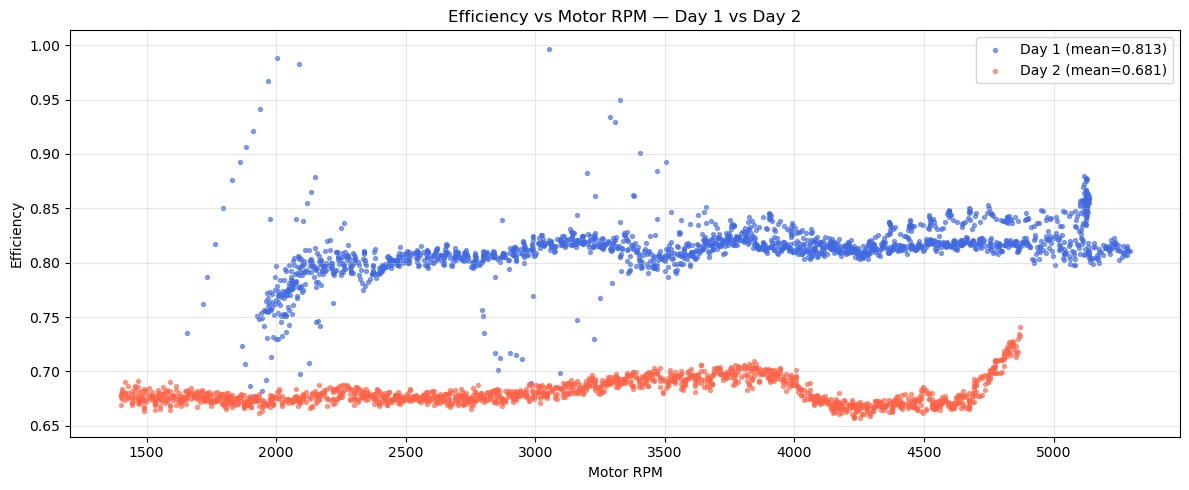


STEP 4: Power breakdown — is the gap from higher P_in or lower P_out?


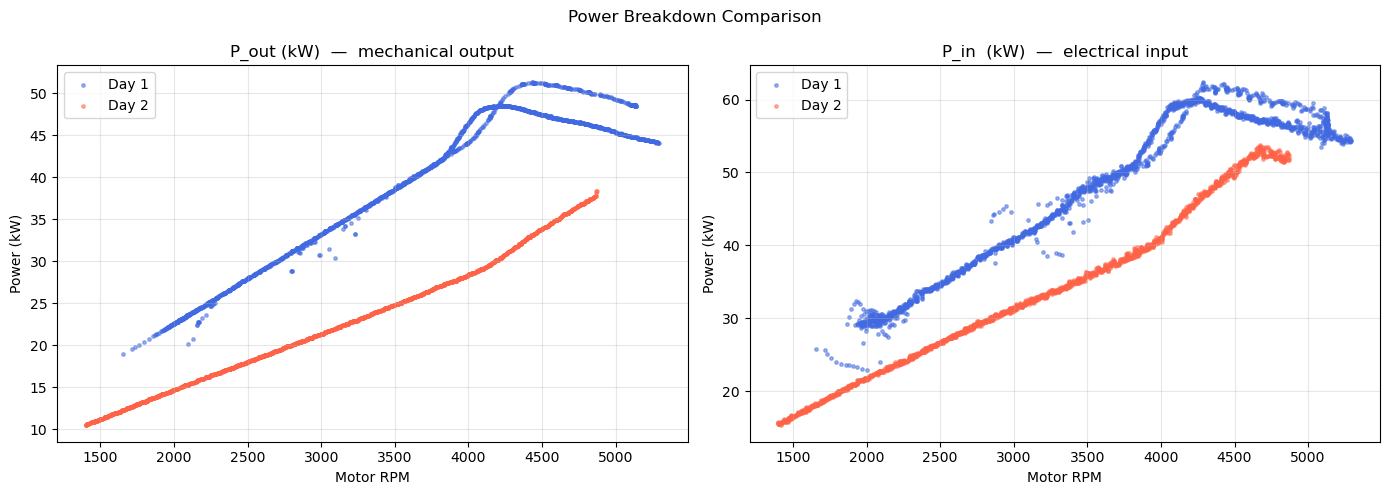

                                    Day 1      Day 2      Delta
Mean P_out (kW)                     39.03      22.81     -16.22
Mean P_in  (kW)                     47.84      33.46     -14.38

STEP 5: Temperature comparison

Metric                     Day1 Mean  Day2 Mean      Delta
------------------------------------------------------------
Motor Temp (°C)                 29.0       33.9       +4.9
Inverter Temp (°C)              24.8       31.5       +6.7
Water In  (°C)                2593.9     3235.7     +641.8
Water Out (°C)                2695.9     3282.9     +587.0
BMS Temp  (°C)                  23.2       27.8       +4.6
Hotspot   (°C)                  37.9       47.3       +9.4


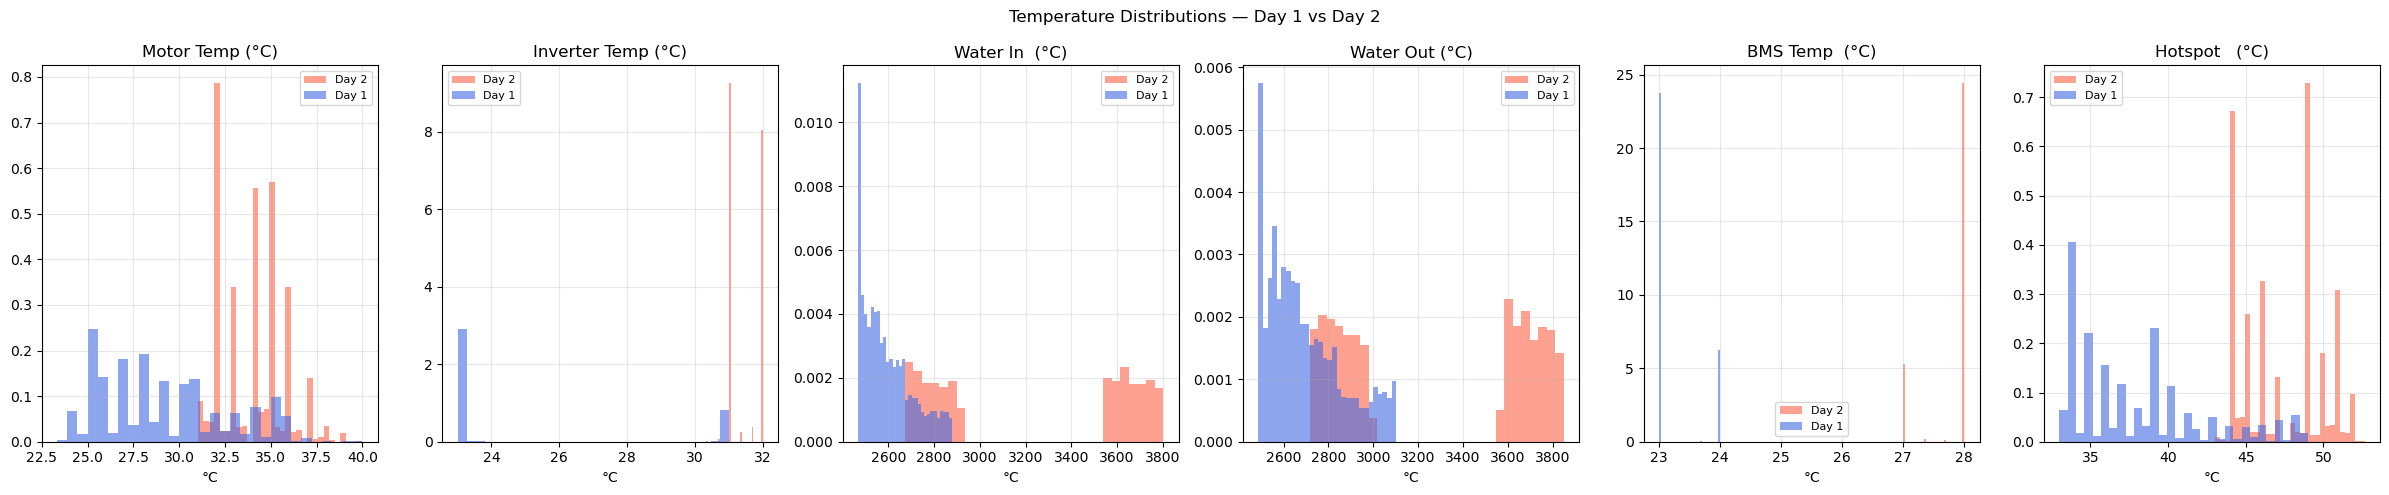


STEP 6: Battery electrical health

Metric                       Day1 Mean    Day2 Mean        Delta
-----------------------------------------------------------------
Pack Resistance (Ω)            447.577      559.345     +111.768
Pack SOC (%)                    70.062       45.818      -24.244
Pack DCL (A)                   175.000      166.971       -8.029
Voltage Sag (V)                794.245      517.909     -276.336
High Cell V (V)              33700.170    33309.672     -390.497
Low  Cell V (V)              32082.733    31506.533     -576.200


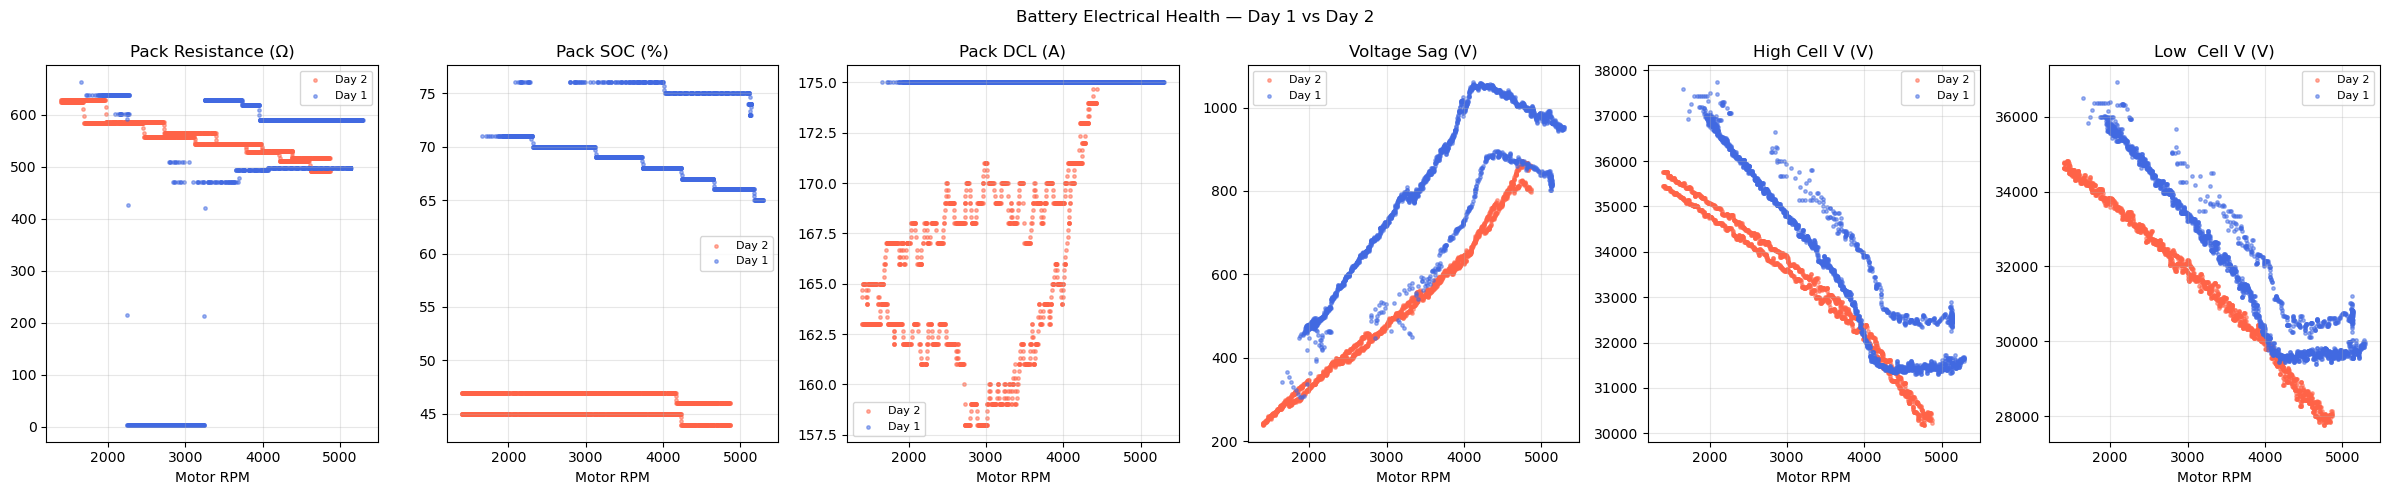


STEP 7: Inverter torque tracking (CMD vs FDB)


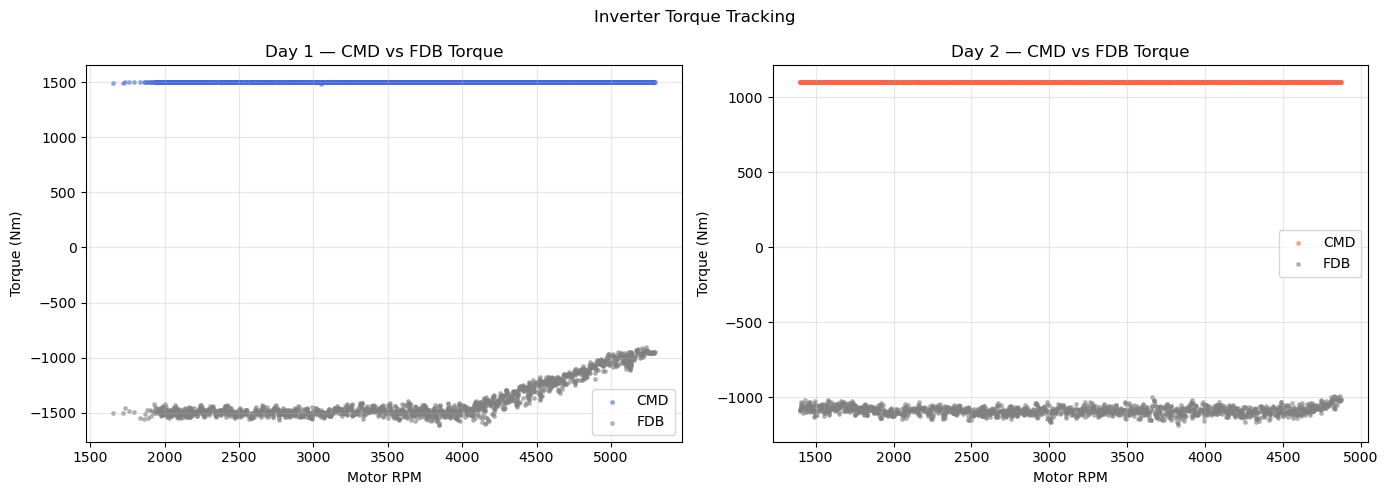

Day 2 mean |CMD - FDB| torque error: 2189.05 Nm
Day 1 mean |CMD - FDB| torque error: 2871.79 Nm
Delta: -682.74 Nm

STEP 8: Summary

Metric                                Day 1        Day 2        Delta  Likely culprit?
--------------------------------------------------------------------------------
Mean Efficiency                       0.813        0.681       -0.132  ⚠ SIGNIFICANT DROP
Mean P_out (kW)                      39.034       22.814      -16.220
Mean P_in  (kW)                      47.845       33.462      -14.382
Motor Temp (°C)                      29.036       33.926       +4.890
Inverter Temp (°C)                   24.752       31.463       +6.711
Water In  (°C)                     2593.879     3235.669     +641.790
Water Out (°C)                     2695.874     3282.867     +586.993
BMS Temp  (°C)                       23.209       27.819       +4.609
Hotspot   (°C)                       37.937       47.345       +9.407
Pack Resistance (Ω)                 447.577      5

In [16]:
day1_result, day2_result = analyse_efficiency_difference(
    # Day 1
    dyno_df_day1=dyno_df,
    motec_files_day1=motec_files,
    dyno_ids_day1=dyno_ids,
    # Day 2
    dyno_files_day2=dyno_matched,
    motec_files_day2=motec_matched,
    # Shared
    target_torque=150,
    rpm_diff_tol=5,
    rolling_window=3,
)